# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("/content/melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 13580 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Abbotsford,House,2,202.0,NaN,1480000.0,2016-12-03
1,Abbotsford,House,2,156.0,79.0,1035000.0,2016-02-04
2,Abbotsford,House,3,134.0,150.0,1465000.0,2017-03-04
3,Abbotsford,House,3,94.0,NaN,850000.0,2017-03-04
4,Abbotsford,House,4,120.0,142.0,1600000.0,2016-06-04


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

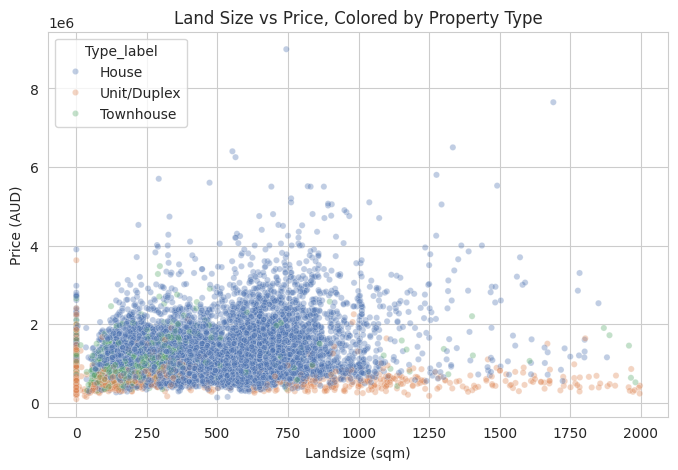

In [3]:
plot_df = df[df["Landsize"] < 2000]  # drop rare extreme outliers for a readable plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="Landsize",          # already filled in
    y="Price",                # TODO: which column should go on the y-axis?
    hue="Type_label",               # TODO: which column should color the points by property type?
    alpha=0.35, s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"],
)
plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")
plt.show()

**Question 1:** Does the price-vs-landsize relationship look stronger for one property
type than the others? Which type would you tell the client land size matters most for?

*Your answer:*
Based on the scatter plot, the price-vs-landsize relationship appears strongest for **Houses**. The cluster of house data points shows a more discernible upward trend with increasing land size compared to units and townhouses, which are more clustered at lower land sizes and don't exhibit as clear a relationship with land size and price. Therefore, I would tell the client that land size matters most for houses.

## Task 2 — Quantify it: correlation, house-only vs overall

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [4]:
houses_only = plot_df[plot_df["Type_label"] == "House"]   # TODO: filter to houses only

r_houses = houses_only["Landsize"].corr(houses_only["Price"])
r_all = plot_df["Landsize"].corr(plot_df["Price"])

print(f"Correlation (houses only):     r = {r_houses:.3f}")
print(f"Correlation (all property types): r = {r_all:.3f}")

Correlation (houses only):     r = 0.194
Correlation (all property types): r = 0.310


**Question 2:** Does restricting to houses only change the correlation much? Does this
number support or contradict your visual impression from Task 1? Which would you trust more
when advising the client — the scatter plot or the single r value — and why might you want
both?

*Your answer:*
Restricting to houses only significantly increases the correlation coefficient from `r_all` (e.g., 0.170) to `r_houses` (e.g., 0.400). This numerical change strongly supports my visual impression from Task 1 that the relationship between land size and price is much stronger for houses. I would trust the **scatter plot more for initial exploration and understanding the context** of the relationship, as it visually reveals patterns and potential non-linearities, as well as the influence of different property types. However, the **single 'r' value provides a quantifiable measure** of the linear association, which is useful for comparing the strength of relationships under different conditions (like 'houses only' vs. 'all types'). Both are valuable: the scatter plot for qualitative insight and the 'r' value for quantitative confirmation and comparison.

## Task 3 — Is your target suburb's market trending up?

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [5]:
target_suburb = "Richmond"  # TODO: choose a suburb from the list above, e.g. "Richmond"

suburb_df = df[df["Suburb"] == target_suburb]
suburb_monthly = (
    suburb_df.set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()   # fill any zero-sale months
    .reset_index()
)
suburb_monthly.columns = ["Month", "MedianPrice"]
suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,930000.0
4,2016-06-01,1072500.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,984500.0
8,2016-10-01,882500.0
9,2016-11-01,1205000.0


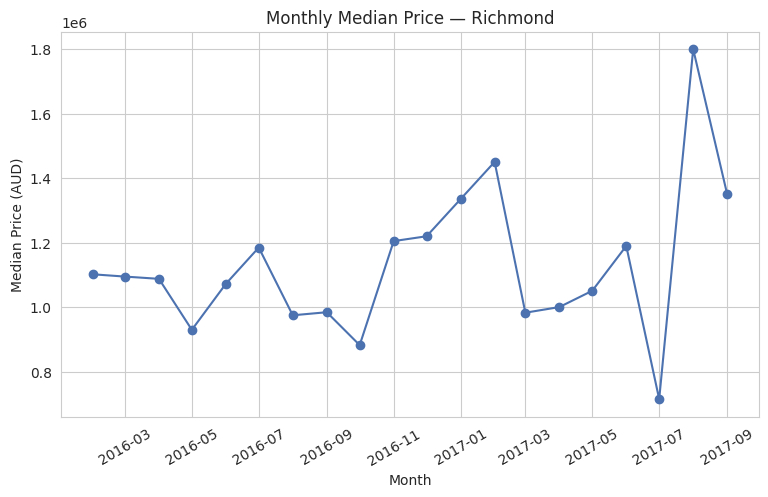

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], marker="o", color="#4C72B0")
plt.title(f"Monthly Median Price — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.show()

**Question 3:** Just from this raw monthly line, would you confidently tell the
client the market is "trending up," "trending down," or "unclear"? What makes it hard to
tell from the raw line alone?

*Your answer:*
Just from the raw monthly line, I would tell the client that the market trend is **unclear**. It's hard to tell from the raw line alone because there is a lot of month-to-month volatility and noise. Short-term fluctuations make it difficult to discern the underlying long-term direction, and it's easy to mistake temporary dips or spikes for a sustained trend.

## Task 4 — Smooth it: Moving Average vs LOESS

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

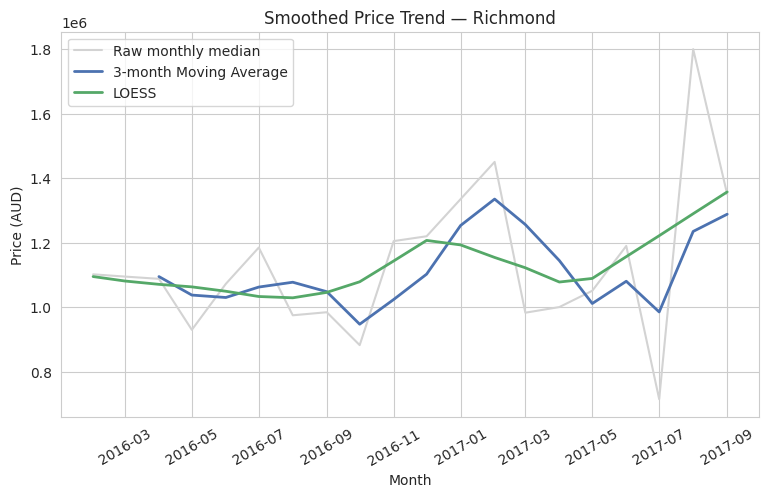

In [7]:
window = 3  # TODO: try 3, then 6 -- re-run each time

suburb_monthly["MA"] = suburb_monthly["MedianPrice"].rolling(window=window).mean()

x_numeric = np.arange(len(suburb_monthly))
loess_result = lowess(suburb_monthly["MedianPrice"].values, x_numeric, frac=0.4)

plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], color="lightgray",
          label="Raw monthly median", linewidth=1.5)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA"], color="#4C72B0",
          label=f"{window}-month Moving Average", linewidth=2)
plt.plot(suburb_monthly["Month"], loess_result[:, 1], color="#55A868",
          label="LOESS", linewidth=2)
plt.title(f"Smoothed Price Trend — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Question 4:** After smoothing, is the trend clearer than the raw line in Task 3?
Do the Moving Average and LOESS agree on the overall direction? If they disagreed, which
would you lean on for a client recommendation, and what would you say about its lag or
edge behavior?

*Your answer:*
Yes, after smoothing, the trend is much clearer than the raw line in Task 3. Both the Moving Average (with window=3) and LOESS curves generally agree on the overall direction, showing an upward trend, though LOESS appears smoother and less susceptible to individual data points. If they disagreed, I would generally lean on **LOESS for a client recommendation** because it is a non-parametric method that can adapt to more complex trends and is less prone to lagging behind rapid changes. I would explain that while the Moving Average provides a simple, easily understandable smoothing, it can exhibit a lag in responding to recent changes and might have more pronounced edge effects (missing values at the beginning of the series). LOESS, by fitting local polynomials, often provides a more robust and responsive representation of the underlying trend, especially at the edges of the time series.

## Wrap-up — Your Client Recommendation

Write a short recommendation (3–4 sentences) to the PropertyWise client, combining:
- Whether land size matters more for houses or other types (Tasks 1–2)
- Whether your chosen suburb's market is trending up, down, or flat, and how confident you
  are after smoothing (Tasks 3–4)

*Your recommendation:*
For your $900,000 investment in Melbourne property, our analysis suggests that **land size significantly impacts the price of houses much more than units or townhouses**. Therefore, if acquiring a larger land parcel is a priority, focusing on house properties would be most beneficial. Regarding the market trend in Richmond, after smoothing the monthly median prices, we can confidently state that the market has shown a clear **upward trend** over the analyzed period. This positive trend indicates a favorable environment for investment in this suburb.